<a href="https://colab.research.google.com/github/theafzalansari/Healthcare_Analytics_for_Doctor_Visits/blob/main/Healthcare_Analytics_for_Doctor_Visits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================================
# HEALTHCARE ANALYTICS FOR DOCTOR VISITS
# CELL 1: IMPORT LIBRARIES AND LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

# Load dataset
file_path = "/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv"

df = pd.read_csv(file_path)

print("=" * 60)
print("HEALTHCARE ANALYTICS FOR DOCTOR VISITS")
print("=" * 60)

print(f"\nRows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

HEALTHCARE ANALYTICS FOR DOCTOR VISITS

Rows    : 5190
Columns : 13


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [8]:
# ============================================================
# CELL 2: DATA UNDERSTANDING AND CLEANING
# ============================================================

print("=" * 60)
print("DATA UNDERSTANDING")
print("=" * 60)

print("\nData Types:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------------------------
# CLEANING
# ------------------------------------------------------------

df_clean = df.copy()

# Remove unnecessary index column
if "Unnamed: 0" in df_clean.columns:
    df_clean.drop(columns=["Unnamed: 0"], inplace=True)

# Remove duplicates
duplicates = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)

print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)

print("Original rows       :", len(df))
print("Duplicates removed  :", duplicates)
print("Final rows          :", len(df_clean))
print(
    "Remaining missing   :",
    df_clean.isnull().sum().sum()
)

display(df_clean.head())

DATA UNDERSTANDING

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB

Missing Values:


,Missing Values
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0



Duplicate Rows: 0

CLEANING SUMMARY
Original rows       : 5190
Duplicates removed  : 1320
Final rows          : 3870
Remaining missing   : 0


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
visits,"3,870.00",0.39,0.90,0.00,0.00,0.00,1.00,9.00
age,"3,870.00",0.41,0.20,0.19,0.22,0.32,0.62,0.72
income,"3,870.00",0.58,0.38,0.00,0.25,0.55,0.90,1.50
illness,"3,870.00",1.67,1.42,0.00,1.00,1.00,2.75,5.00
reduced,"3,870.00",1.15,3.29,0.00,0.00,0.00,0.00,14.00
health,"3,870.00",1.58,2.33,0.00,0.00,1.00,2.00,12.00



CATEGORICAL VARIABLES

GENDER
gender
female    2068
male      1802
Name: count, dtype: int64

PRIVATE
private
no     2088
yes    1782
Name: count, dtype: int64

FREEPOOR
freepoor
no     3676
yes     194
Name: count, dtype: int64

FREEREPAT
freerepat
no     3102
yes     768
Name: count, dtype: int64

NCHRONIC
nchronic
no     2192
yes    1678
Name: count, dtype: int64

LCHRONIC
lchronic
no     3294
yes     576
Name: count, dtype: int64


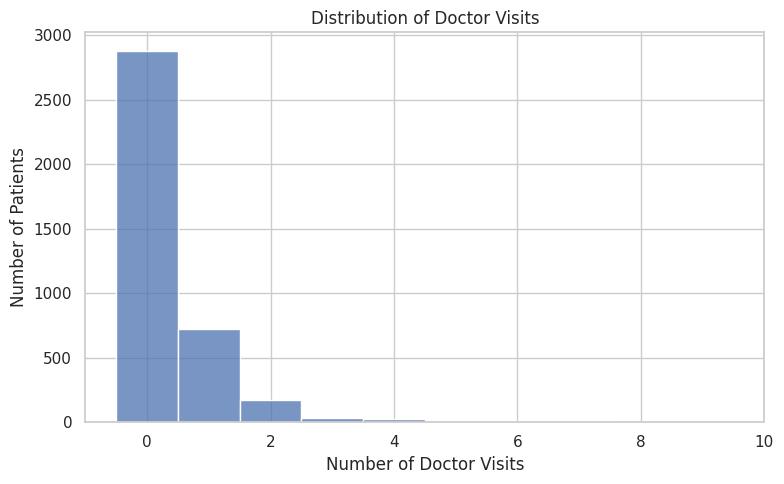

In [9]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

display(df_clean.describe().T)

print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

categorical_columns = [
    "gender",
    "private",
    "freepoor",
    "freerepat",
    "nchronic",
    "lchronic"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(df_clean[column].value_counts())

# ------------------------------------------------------------
# DOCTOR VISIT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="visits",
    discrete=True
)

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

DEMOGRAPHIC ANALYSIS

Doctor Visits by Gender:


,Patients,Average_Visits,Median_Visits
gender,,,
female,2068,0.45,0.00
male,1802,0.32,0.00


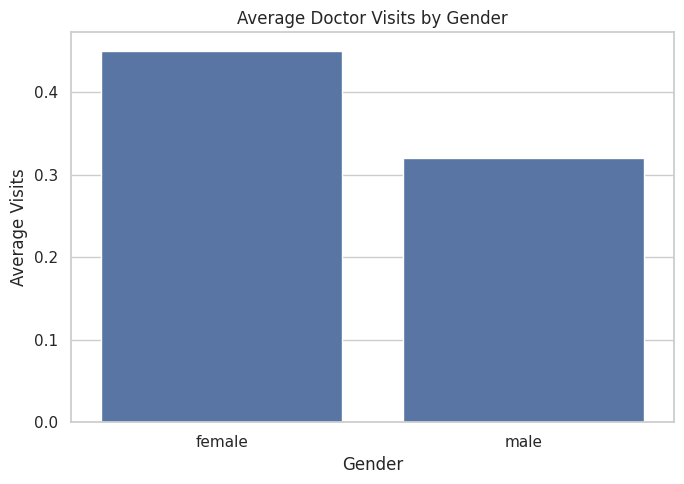

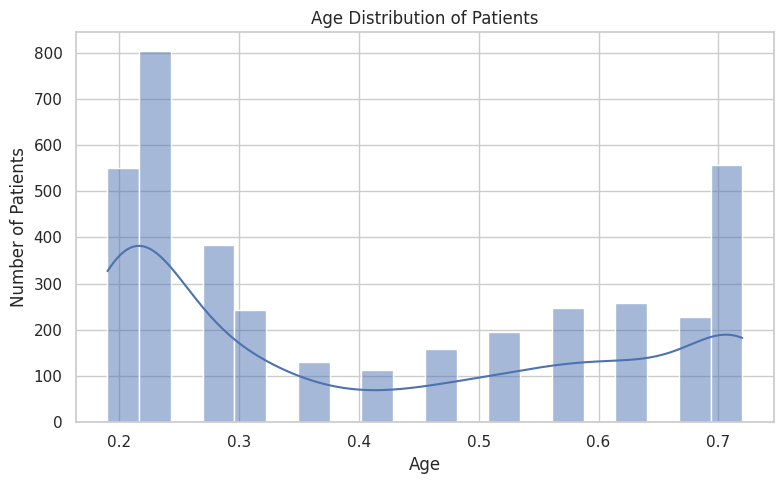

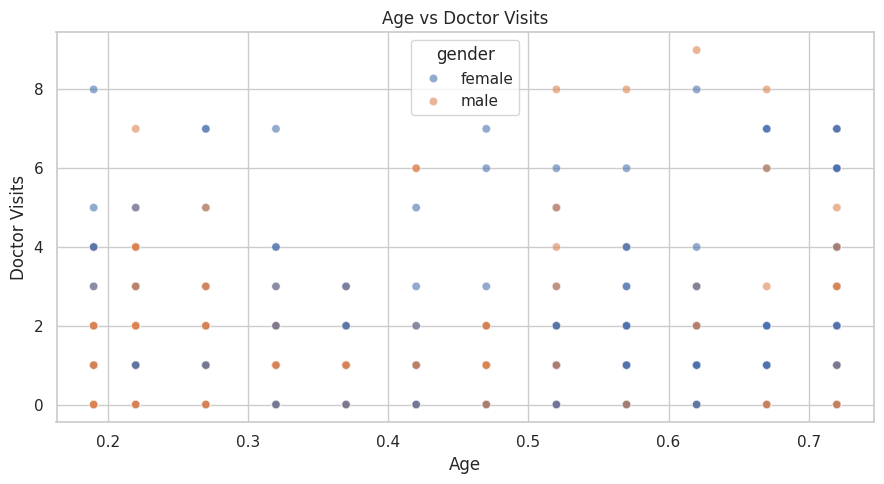

In [10]:
# ============================================================
# CELL 4: DEMOGRAPHIC ANALYSIS
# ============================================================

print("=" * 60)
print("DEMOGRAPHIC ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# GENDER
# ------------------------------------------------------------

gender_analysis = df_clean.groupby("gender").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean"),
    Median_Visits=("visits", "median")
).round(2)

print("\nDoctor Visits by Gender:")
display(gender_analysis)

# Gender visualization
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="gender",
    y="visits",
    estimator="mean",
    errorbar=None
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Visits")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# AGE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# AGE VS VISITS
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="visits",
    hue="gender",
    alpha=0.6
)

plt.title("Age vs Doctor Visits")
plt.xlabel("Age")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

HEALTH AND ILLNESS ANALYSIS

Illness Score vs Doctor Visits:


,illness,Patients,Average_Visits,Median_Visits
0,0,870,0.13,0.00
1,1,1211,0.38,0.00
2,2,821,0.45,0.00
3,3,485,0.45,0.00
4,4,258,0.61,0.00
5,5,225,0.85,0.00


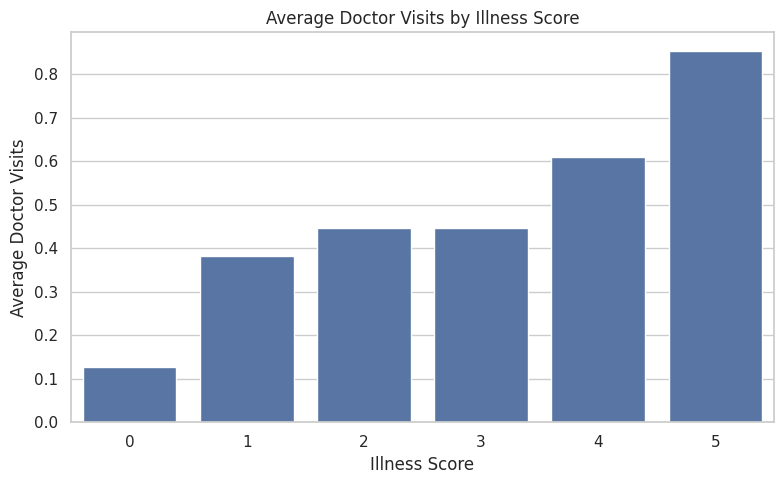


General Health vs Doctor Visits:


,health,Patients,Average_Visits
0,0,1851,0.30
1,1,719,0.37
2,2,419,0.40
3,3,264,0.42
4,4,185,0.54
5,5,132,0.53
6,6,102,0.64
7,7,61,0.92
8,8,41,0.49
9,9,32,0.66


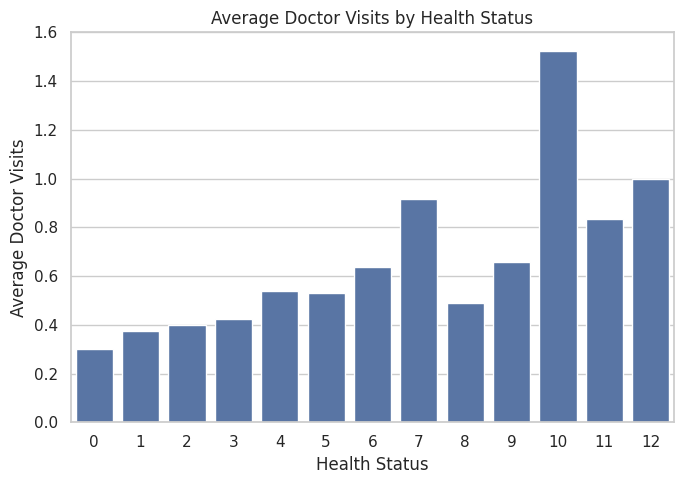

In [11]:
# ============================================================
# CELL 5: HEALTH AND ILLNESS ANALYSIS
# ============================================================

print("=" * 60)
print("HEALTH AND ILLNESS ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# ILLNESS
# ------------------------------------------------------------

illness_analysis = df_clean.groupby("illness").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean"),
    Median_Visits=("visits", "median")
).reset_index()

print("\nIllness Score vs Doctor Visits:")
display(illness_analysis.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=illness_analysis,
    x="illness",
    y="Average_Visits",
    errorbar=None
)

plt.title("Average Doctor Visits by Illness Score")
plt.xlabel("Illness Score")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# GENERAL HEALTH
# ------------------------------------------------------------

health_analysis = df_clean.groupby("health").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean")
).reset_index()

print("\nGeneral Health vs Doctor Visits:")
display(health_analysis.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(
    data=health_analysis,
    x="health",
    y="Average_Visits",
    errorbar=None
)

plt.title("Average Doctor Visits by Health Status")
plt.xlabel("Health Status")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

INCOME AND HEALTHCARE ACCESS

Income vs Doctor Visits:


,income,Patients,Average_Visits
0,0.00,71,0.41
1,0.01,35,0.49
2,0.06,77,0.21
3,0.15,215,0.40
4,0.25,800,0.57
5,0.35,368,0.45
6,0.45,323,0.37
7,0.55,342,0.34
8,0.65,341,0.33
9,0.75,319,0.34


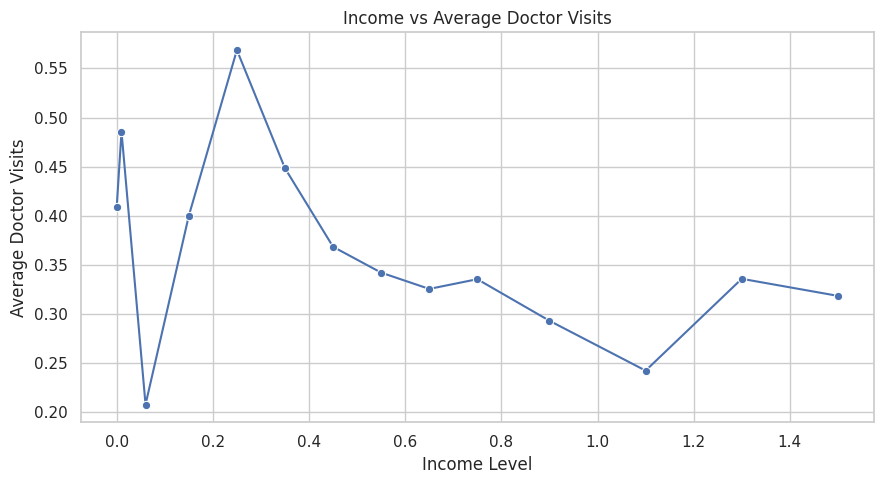


Private Insurance vs Doctor Visits:


,private,Patients,Average_Visits
0,no,2088,0.40
1,yes,1782,0.37


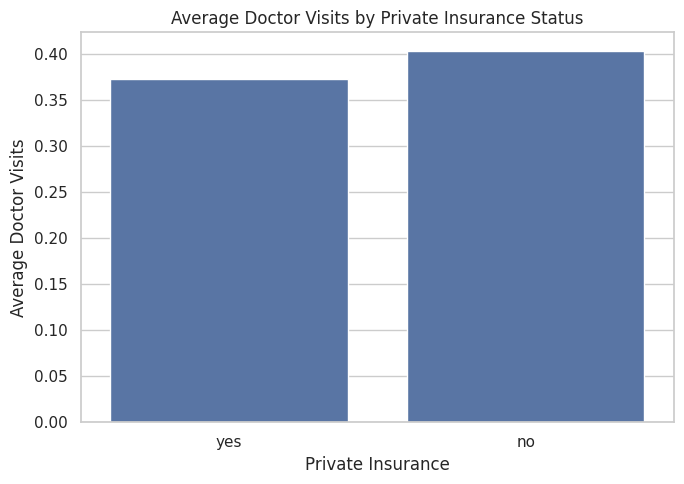

In [12]:
# ============================================================
# CELL 6: INCOME AND HEALTHCARE ACCESS
# ============================================================

print("=" * 60)
print("INCOME AND HEALTHCARE ACCESS")
print("=" * 60)

# ------------------------------------------------------------
# INCOME VS VISITS
# ------------------------------------------------------------

income_analysis = df_clean.groupby("income").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean")
).reset_index()

print("\nIncome vs Doctor Visits:")
display(income_analysis.round(2))

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=income_analysis,
    x="income",
    y="Average_Visits",
    marker="o"
)

plt.title("Income vs Average Doctor Visits")
plt.xlabel("Income Level")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRIVATE INSURANCE
# ------------------------------------------------------------

private_analysis = df_clean.groupby("private").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean")
).reset_index()

print("\nPrivate Insurance vs Doctor Visits:")
display(private_analysis.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="private",
    y="visits",
    estimator="mean",
    errorbar=None
)

plt.title("Average Doctor Visits by Private Insurance Status")
plt.xlabel("Private Insurance")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

CHRONIC CONDITIONS AND ACTIVITY REDUCTION

Chronic Condition Analysis:


,nchronic,lchronic,Patients,Average_Visits
0,no,no,1616,0.29
1,no,yes,576,0.63
2,yes,no,1678,0.41


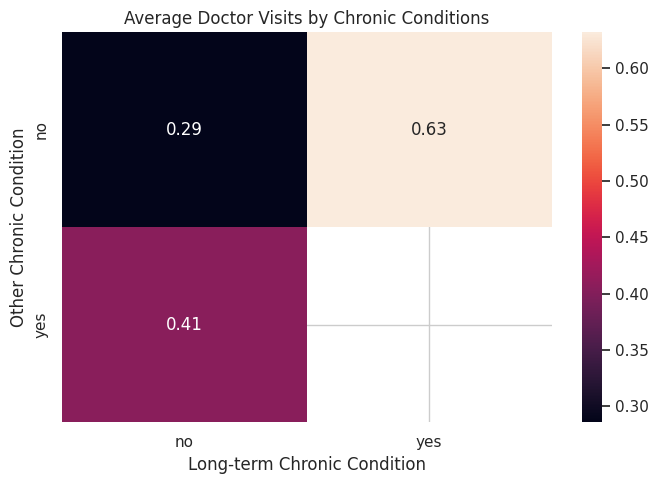


Reduced Activity vs Doctor Visits:


,reduced,Patients,Average_Visits
0,0,3137,0.24
1,1,175,0.36
2,2,108,0.57
3,3,74,1.09
4,4,45,0.80
5,5,40,1.27
6,6,17,1.18
7,7,38,1.18
8,8,17,1.18
9,9,7,1.71


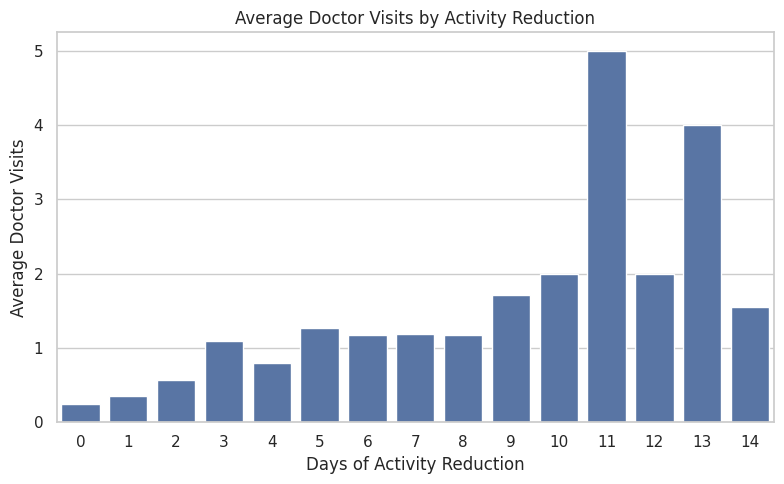

In [13]:
# ============================================================
# CELL 7: CHRONIC CONDITIONS AND ACTIVITY REDUCTION
# ============================================================

print("=" * 60)
print("CHRONIC CONDITIONS AND ACTIVITY REDUCTION")
print("=" * 60)

# ------------------------------------------------------------
# CHRONIC CONDITIONS
# ------------------------------------------------------------

chronic_analysis = df_clean.groupby(
    ["nchronic", "lchronic"]
).agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean")
).reset_index()

print("\nChronic Condition Analysis:")
display(chronic_analysis.round(2))

# Heatmap
chronic_pivot = pd.pivot_table(
    df_clean,
    values="visits",
    index="nchronic",
    columns="lchronic",
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    chronic_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Average Doctor Visits by Chronic Conditions")
plt.xlabel("Long-term Chronic Condition")
plt.ylabel("Other Chronic Condition")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# REDUCED ACTIVITY
# ------------------------------------------------------------

reduced_analysis = df_clean.groupby("reduced").agg(
    Patients=("visits", "count"),
    Average_Visits=("visits", "mean")
).reset_index()

print("\nReduced Activity vs Doctor Visits:")
display(reduced_analysis.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="reduced",
    y="visits",
    estimator="mean",
    errorbar=None
)

plt.title("Average Doctor Visits by Activity Reduction")
plt.xlabel("Days of Activity Reduction")
plt.ylabel("Average Doctor Visits")
plt.tight_layout()
plt.show()

MULTIVARIATE ANALYSIS


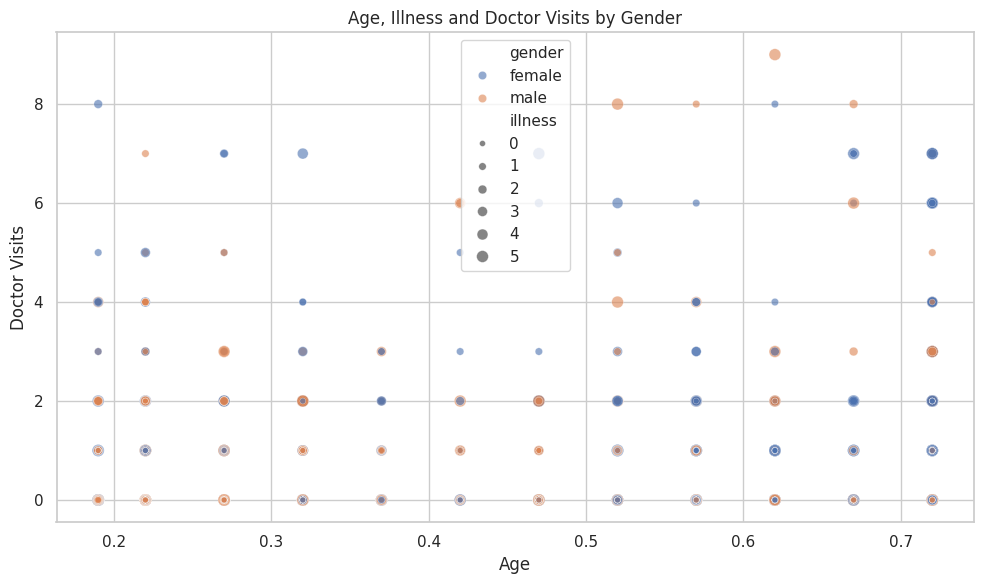

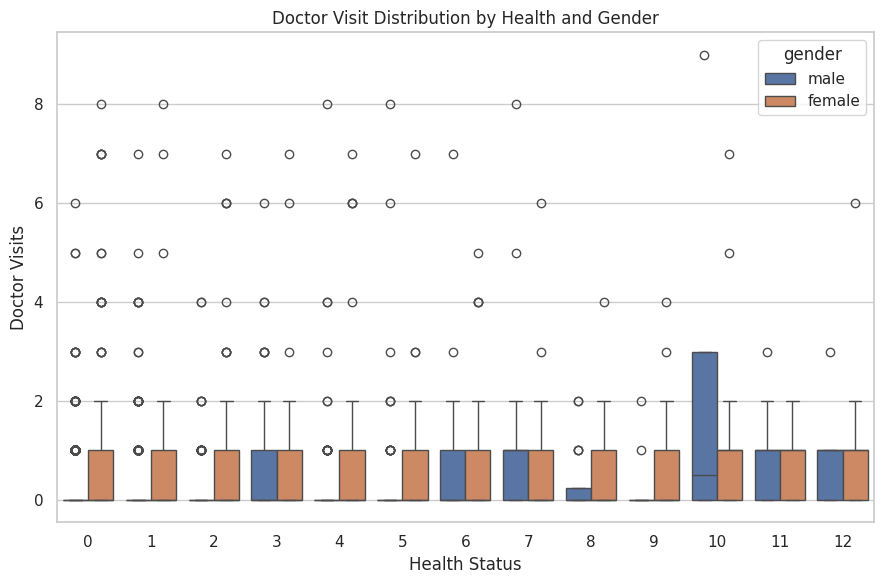


Average Visits by Gender and Private Insurance:


private,no,yes
gender,,
female,0.48,0.41
male,0.32,0.32


In [14]:
# ============================================================
# CELL 8: MULTIVARIATE ANALYSIS
# ============================================================

print("=" * 60)
print("MULTIVARIATE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# AGE + VISITS + GENDER
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="visits",
    hue="gender",
    size="illness",
    alpha=0.6
)

plt.title("Age, Illness and Doctor Visits by Gender")
plt.xlabel("Age")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ILLNESS + HEALTH + VISITS
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="health",
    y="visits",
    hue="gender"
)

plt.title("Doctor Visit Distribution by Health and Gender")
plt.xlabel("Health Status")
plt.ylabel("Doctor Visits")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# INSURANCE + GENDER
# ------------------------------------------------------------

insurance_gender = pd.pivot_table(
    df_clean,
    values="visits",
    index="gender",
    columns="private",
    aggfunc="mean"
)

print("\nAverage Visits by Gender and Private Insurance:")
display(insurance_gender.round(2))

CORRELATION ANALYSIS


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
visits,1.00,-0.07,0.12,-0.08,0.19,0.40,0.15,-0.02,-0.05,0.12,0.02,0.11
gender,-0.07,1.00,-0.20,0.23,-0.10,-0.04,-0.05,-0.07,0.07,-0.18,-0.10,-0.03
age,0.12,-0.20,1.00,-0.20,0.17,0.11,0.00,-0.03,-0.18,0.54,0.22,0.13
income,-0.08,0.23,-0.20,1.00,-0.13,-0.05,-0.10,0.26,-0.17,-0.36,-0.02,-0.07
illness,0.19,-0.10,0.17,-0.13,1.00,0.19,0.31,-0.06,-0.04,0.19,0.18,0.19
reduced,0.40,-0.04,0.11,-0.05,0.19,1.00,0.25,-0.05,-0.02,0.11,-0.02,0.20
health,0.15,-0.05,0.00,-0.10,0.31,0.25,1.00,-0.08,0.04,0.09,-0.01,0.15
private,-0.02,-0.07,-0.03,0.26,-0.06,-0.05,-0.08,1.00,-0.21,-0.46,0.05,-0.06
freepoor,-0.05,0.07,-0.18,-0.17,-0.04,-0.02,0.04,-0.21,1.00,-0.11,-0.07,-0.01
freerepat,0.12,-0.18,0.54,-0.36,0.19,0.11,0.09,-0.46,-0.11,1.00,0.09,0.19


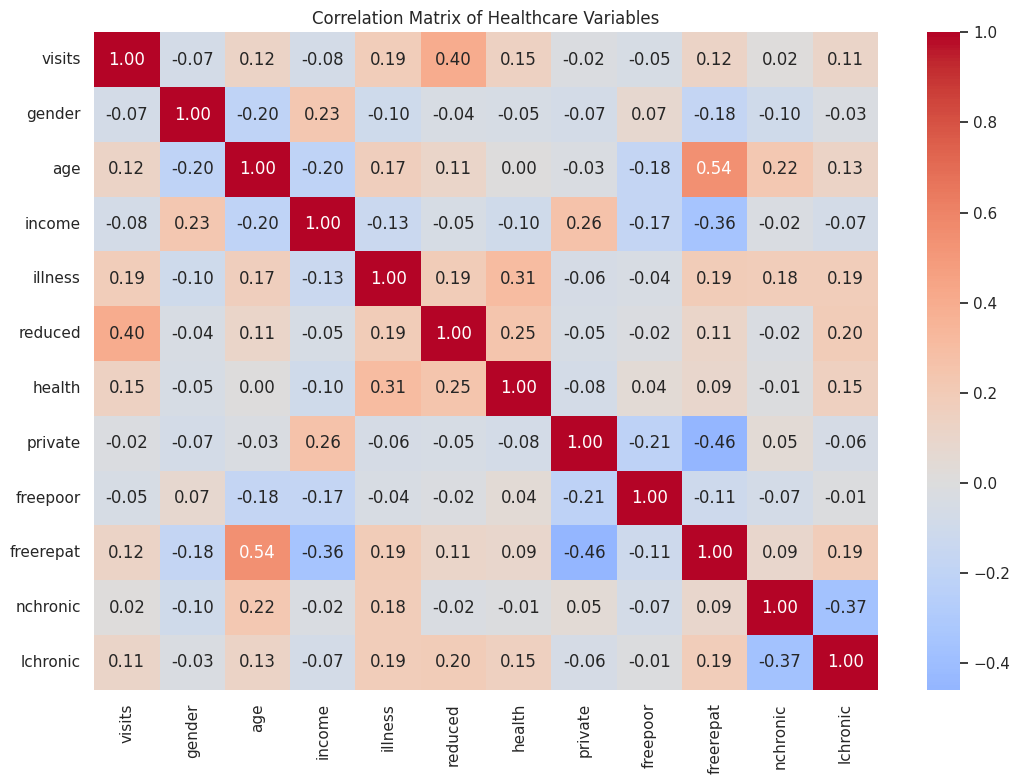


Variables Most Associated with Doctor Visits:


,visits
reduced,0.40
illness,0.18
health,0.15
age,0.12
freerepat,0.12
lchronic,0.11
income,-0.08
gender,-0.07
freepoor,-0.05
private,-0.02


In [15]:
# ============================================================
# CELL 9: CORRELATION ANALYSIS
# ============================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

corr_df = df_clean.copy()

# Convert binary categorical variables to numeric
binary_columns = [
    "gender",
    "private",
    "freepoor",
    "freerepat",
    "nchronic",
    "lchronic"
]

for column in binary_columns:

    if column in corr_df.columns:

        unique_values = corr_df[column].dropna().unique()

        if set(unique_values).issubset(
            {"yes", "no"}
        ):
            corr_df[column] = corr_df[column].map({
                "yes": 1,
                "no": 0
            })

        elif set(unique_values).issubset(
            {"male", "female"}
        ):
            corr_df[column] = corr_df[column].map({
                "male": 1,
                "female": 0
            })

# Select numerical columns
numeric_columns = corr_df.select_dtypes(
    include=np.number
).columns

correlation_matrix = corr_df[
    numeric_columns
].corr()

display(correlation_matrix.round(2))

# ------------------------------------------------------------
# HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Healthcare Variables")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VARIABLES MOST ASSOCIATED WITH VISITS
# ------------------------------------------------------------

visit_correlations = (
    correlation_matrix["visits"]
    .drop("visits")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nVariables Most Associated with Doctor Visits:")
display(visit_correlations.round(3))

In [16]:
# ============================================================
# CELL 10: STATISTICAL ANALYSIS AND FINAL FINDINGS
# ============================================================

print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# T-TEST: GENDER VS DOCTOR VISITS
# ------------------------------------------------------------

male_visits = df_clean[
    df_clean["gender"] == "male"
]["visits"]

female_visits = df_clean[
    df_clean["gender"] == "female"
]["visits"]

t_test = stats.ttest_ind(
    male_visits,
    female_visits,
    equal_var=False
)

print("\nGender and Doctor Visits")
print("-" * 40)
print("Male average visits  :", round(male_visits.mean(), 3))
print("Female average visits:", round(female_visits.mean(), 3))
print("T-statistic          :", round(t_test.statistic, 4))
print("P-value              :", round(t_test.pvalue, 4))

if t_test.pvalue < 0.05:
    print("Result: Difference is statistically significant (p < 0.05).")
else:
    print("Result: Difference is not statistically significant (p >= 0.05).")

# ------------------------------------------------------------
# ANOVA: ILLNESS SCORE VS VISITS
# ------------------------------------------------------------

illness_groups = [
    group["visits"].values
    for _, group in df_clean.groupby("illness")
]

anova_result = stats.f_oneway(*illness_groups)

print("\n" + "-" * 40)
print("Illness Score and Doctor Visits")
print("-" * 40)
print("F-statistic:", round(anova_result.statistic, 4))
print("P-value    :", round(anova_result.pvalue, 4))

if anova_result.pvalue < 0.05:
    print(
        "Result: Doctor visits differ significantly "
        "across illness-score groups."
    )
else:
    print(
        "Result: No statistically significant difference "
        "was detected across illness-score groups."
    )

# ------------------------------------------------------------
# FINAL KEY FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA-DRIVEN FINDINGS")
print("=" * 70)

# Highest average visits by illness
illness_means = (
    df_clean.groupby("illness")["visits"]
    .mean()
    .sort_values(ascending=False)
)

print(
    f"\n1. Highest average visits by illness score: "
    f"{illness_means.index[0]} "
    f"({illness_means.iloc[0]:.2f} visits)"
)

# Gender
gender_means = (
    df_clean.groupby("gender")["visits"]
    .mean()
    .sort_values(ascending=False)
)

print(
    f"2. Highest average visits by gender: "
    f"{gender_means.index[0]} "
    f"({gender_means.iloc[0]:.2f} visits)"
)

# Health
health_means = (
    df_clean.groupby("health")["visits"]
    .mean()
    .sort_values(ascending=False)
)

print(
    f"3. Health group with highest average visits: "
    f"{health_means.index[0]} "
    f"({health_means.iloc[0]:.2f} visits)"
)

# Income
income_means = (
    df_clean.groupby("income")["visits"]
    .mean()
    .sort_values(ascending=False)
)

print(
    f"4. Income group with highest average visits: "
    f"{income_means.index[0]} "
    f"({income_means.iloc[0]:.2f} visits)"
)

# Private insurance
private_means = (
    df_clean.groupby("private")["visits"]
    .mean()
    .sort_values(ascending=False)
)

print(
    f"5. Insurance group with highest average visits: "
    f"{private_means.index[0]} "
    f"({private_means.iloc[0]:.2f} visits)"
)

# Dataset summary
print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print("Total records analyzed:", len(df_clean))
print("Average doctor visits :", round(df_clean["visits"].mean(), 2))
print("Median doctor visits  :", round(df_clean["visits"].median(), 2))
print(
    "Maximum doctor visits  :",
    df_clean["visits"].max()
)

# Save cleaned dataset
df_clean.to_csv(
    "/content/cleaned_healthcare_doctor_visits.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")

STATISTICAL ANALYSIS

Gender and Doctor Visits
----------------------------------------
Male average visits  : 0.32
Female average visits: 0.45
T-statistic          : -4.541
P-value              : 0.0
Result: Difference is statistically significant (p < 0.05).

----------------------------------------
Illness Score and Doctor Visits
----------------------------------------
F-statistic: 32.0816
P-value    : 0.0
Result: Doctor visits differ significantly across illness-score groups.

FINAL DATA-DRIVEN FINDINGS

1. Highest average visits by illness score: 5 (0.85 visits)
2. Highest average visits by gender: female (0.45 visits)
3. Health group with highest average visits: 10 (1.52 visits)
4. Income group with highest average visits: 0.25 (0.57 visits)
5. Insurance group with highest average visits: no (0.40 visits)

PROJECT SUMMARY
Total records analyzed: 3870
Average doctor visits : 0.39
Median doctor visits  : 0.0
Maximum doctor visits  : 9

Cleaned dataset saved successfully.
